# BGL Log Feature Extraction (Assignment Part 2)

This notebook uses the **BGL.log** dataset and extracts features on **fixed 5-minute time windows** so the temporal structure is preserved.

It applies three substantially different feature extraction methods:
1. Manual structured window features.
2. Topic-model features with **LDA** (window documents -> topic distributions).
3. TF-IDF features built from the concatenated messages in each 5-minute window.

Requirement coverage:
- At least one visualization: manual and text-feature visualizations are included.
- At least one downstream classifier: logistic regression on 5-minute window TF-IDF features (time-ordered split).
- Additional classifier: **numeric window features + TF-IDF → TruncatedSVD**, concatenated and fed to logistic regression (same split).

In [9]:
from collections import Counter
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

WINDOW_MINUTES = 5
WINDOW_FLOOR = f'{WINDOW_MINUTES}min'

project_root = Path.cwd()
if not (project_root / 'BGL.log').exists():
    project_root = project_root.parent

log_path = project_root / 'BGL.log'
if not log_path.exists():
    raise FileNotFoundError(f'BGL.log not found from resolved root: {project_root}')

artifacts_dir = project_root / 'artifacts' / 'bgl_log_feature_extraction'
artifacts_dir.mkdir(parents=True, exist_ok=True)

print('Project root:', project_root)
print('Log path:', log_path)
print('Artifacts dir:', artifacts_dir)
print('Window size:', WINDOW_MINUTES, 'minutes')

Project root: /Users/yangjiening/Documents/CMU/Courses/18752 estimation detection and learning/log-ml
Log path: /Users/yangjiening/Documents/CMU/Courses/18752 estimation detection and learning/log-ml/BGL.log
Artifacts dir: /Users/yangjiening/Documents/CMU/Courses/18752 estimation detection and learning/log-ml/artifacts/bgl_log_feature_extraction
Window size: 5 minutes


In [10]:
def parse_bgl_line(line: str):
    parts = line.split(' ', 9)
    if len(parts) < 10:
        return None

    return {
        'label': parts[0],
        'unix_ts': parts[1],
        'date_token': parts[2],
        'location': parts[3],
        'timestamp_text': parts[4],
        'location_dup': parts[5],
        'facility': parts[6],
        'component': parts[7],
        'level': parts[8],
        'message': parts[9],
    }


def build_bgl_window_features(path: Path, window_minutes: int = 5):
    window_floor = f'{window_minutes}min'
    window_delta = pd.Timedelta(minutes=window_minutes)
    window_map = {}
    total_lines = 0
    parsed_lines = 0

    def init_bucket(window_start: pd.Timestamp):
        return {
            'window_start': window_start,
            'window_end': window_start + window_delta,
            'event_count': 0,
            'anomaly_count': 0,
            'message_length_sum': 0,
            'message_length_sq_sum': 0,
            'message_length_min': None,
            'message_length_max': None,
            'message_token_count_sum': 0,
            'message_token_count_sq_sum': 0,
            'message_token_count_min': None,
            'message_token_count_max': None,
            'digit_event_count': 0,
            'hex_event_count': 0,
            'cache_event_count': 0,
            'memory_event_count': 0,
            'network_event_count': 0,
            'level_counts': Counter(),
            'facility_counts': Counter(),
            'component_counts': Counter(),
            'messages': [],
            'timestamps': [],
        }

    with path.open('r', errors='ignore') as f:
        for total_lines, line in enumerate(f, start=1):
            rec = parse_bgl_line(line.rstrip('\n'))
            if rec is None:
                continue

            timestamp = pd.to_datetime(
                rec['timestamp_text'],
                format='%Y-%m-%d-%H.%M.%S.%f',
                errors='coerce',
            )
            if pd.isna(timestamp):
                continue

            parsed_lines += 1
            window_start = timestamp.floor(window_floor)
            bucket = window_map.get(window_start)
            if bucket is None:
                bucket = init_bucket(window_start)
                window_map[window_start] = bucket

            message = '' if rec['message'] is None else str(rec['message'])
            message_length = len(message)
            message_token_count = len(message.split()) if message else 0
            has_digit = int(bool(re.search(r'\d', message)))
            has_hex_like = int(bool(re.search(r'0x|[A-Fa-f0-9]{8,}', message)))
            has_cache_word = int(bool(re.search(r'cache|tlb|l1|l2', message, flags=re.IGNORECASE)))
            has_memory_word = int(bool(re.search(r'memory|parity|ecc', message, flags=re.IGNORECASE)))
            has_network_word = int(bool(re.search(r'torus|link|packet|network', message, flags=re.IGNORECASE)))

            bucket['event_count'] += 1
            bucket['anomaly_count'] += int(rec['label'] != '-')
            bucket['message_length_sum'] += message_length
            bucket['message_length_sq_sum'] += message_length ** 2
            bucket['message_token_count_sum'] += message_token_count
            bucket['message_token_count_sq_sum'] += message_token_count ** 2
            bucket['message_length_min'] = message_length if bucket['message_length_min'] is None else min(bucket['message_length_min'], message_length)
            bucket['message_length_max'] = message_length if bucket['message_length_max'] is None else max(bucket['message_length_max'], message_length)
            bucket['message_token_count_min'] = message_token_count if bucket['message_token_count_min'] is None else min(bucket['message_token_count_min'], message_token_count)
            bucket['message_token_count_max'] = message_token_count if bucket['message_token_count_max'] is None else max(bucket['message_token_count_max'], message_token_count)
            bucket['digit_event_count'] += has_digit
            bucket['hex_event_count'] += has_hex_like
            bucket['cache_event_count'] += has_cache_word
            bucket['memory_event_count'] += has_memory_word
            bucket['network_event_count'] += has_network_word
            bucket['level_counts'][rec['level']] += 1
            bucket['facility_counts'][rec['facility']] += 1
            bucket['component_counts'][rec['component']] += 1
            bucket['messages'].append(message)
            bucket['timestamps'].append(timestamp)

    records = []
    for window_index, window_start in enumerate(sorted(window_map.keys())):
        bucket = window_map[window_start]
        event_count = bucket['event_count']
        anomaly_count = bucket['anomaly_count']
        level_counts = bucket['level_counts']
        facility_counts = bucket['facility_counts']
        component_counts = bucket['component_counts']
        timestamps = bucket['timestamps']

        message_length_mean = bucket['message_length_sum'] / event_count if event_count else 0.0
        message_token_count_mean = bucket['message_token_count_sum'] / event_count if event_count else 0.0
        message_length_var = max(bucket['message_length_sq_sum'] / event_count - message_length_mean ** 2, 0.0) if event_count else 0.0
        message_token_count_var = max(bucket['message_token_count_sq_sum'] / event_count - message_token_count_mean ** 2, 0.0) if event_count else 0.0
        gap_mean_seconds = 0.0
        gap_std_seconds = 0.0
        if len(timestamps) > 1:
            gaps = pd.Series(sorted(timestamps)).diff().dt.total_seconds().dropna()
            if not gaps.empty:
                gap_mean_seconds = float(gaps.mean())
                gap_std_seconds = float(gaps.std(ddof=0)) if len(gaps) > 1 else 0.0

        dominant_level_count = level_counts.most_common(1)[0][1] if level_counts else 0
        dominant_facility_count = facility_counts.most_common(1)[0][1] if facility_counts else 0
        dominant_component_count = component_counts.most_common(1)[0][1] if component_counts else 0

        records.append({
            'window_index': window_index,
            'window_start': window_start,
            'window_end': bucket['window_end'],
            'window_minutes': window_minutes,
            'event_count': event_count,
            'anomaly_count': anomaly_count,
            'is_anomaly': int(anomaly_count > 0),
            'anomaly_rate': anomaly_count / event_count if event_count else 0.0,
            'message_length_mean': message_length_mean,
            'message_length_std': float(np.sqrt(message_length_var)),
            'message_length_min': int(bucket['message_length_min']) if bucket['message_length_min'] is not None else 0,
            'message_length_max': int(bucket['message_length_max']) if bucket['message_length_max'] is not None else 0,
            'message_token_count_mean': message_token_count_mean,
            'message_token_count_std': float(np.sqrt(message_token_count_var)),
            'message_token_count_min': int(bucket['message_token_count_min']) if bucket['message_token_count_min'] is not None else 0,
            'message_token_count_max': int(bucket['message_token_count_max']) if bucket['message_token_count_max'] is not None else 0,
            'digit_event_rate': bucket['digit_event_count'] / event_count if event_count else 0.0,
            'hex_event_rate': bucket['hex_event_count'] / event_count if event_count else 0.0,
            'cache_event_rate': bucket['cache_event_count'] / event_count if event_count else 0.0,
            'memory_event_rate': bucket['memory_event_count'] / event_count if event_count else 0.0,
            'network_event_rate': bucket['network_event_count'] / event_count if event_count else 0.0,
            'unique_level_count': len(level_counts),
            'dominant_level_share': dominant_level_count / event_count if event_count else 0.0,
            'unique_facility_count': len(facility_counts),
            'dominant_facility_share': dominant_facility_count / event_count if event_count else 0.0,
            'unique_component_count': len(component_counts),
            'dominant_component_share': dominant_component_count / event_count if event_count else 0.0,
            'mean_interarrival_seconds': gap_mean_seconds,
            'std_interarrival_seconds': gap_std_seconds,
            'window_text': ' '.join(bucket['messages']),
            'timestamp_count': len(timestamps),
        })

    window_df = pd.DataFrame(records).sort_values('window_start').reset_index(drop=True)
    return window_df, total_lines, parsed_lines

In [11]:
window_df, total_lines_scanned, parsed_lines = build_bgl_window_features(log_path, window_minutes=WINDOW_MINUTES)

print(f'Total lines scanned: {total_lines_scanned:,}')
print(f'Parsed log events: {parsed_lines:,}')
print(f'5-minute windows created: {len(window_df):,}')
print('Window label distribution (0=normal,1=anomaly):')
print(window_df['is_anomaly'].value_counts(normalize=True).rename('ratio'))
print('Window span:')
print(window_df[['window_start', 'window_end']].head(3))

display(window_df.head(10))

Total lines scanned: 4,747,963
Parsed log events: 4,713,493
5-minute windows created: 14,494
Window label distribution (0=normal,1=anomaly):
is_anomaly
0    0.92728
1    0.07272
Name: ratio, dtype: float64
Window span:
         window_start          window_end
0 2005-06-03 15:40:00 2005-06-03 15:45:00
1 2005-06-03 15:45:00 2005-06-03 15:50:00
2 2005-06-03 15:50:00 2005-06-03 15:55:00


,window_index,window_start,window_end,window_minutes,event_count,anomaly_count,is_anomaly,anomaly_rate,message_length_mean,message_length_std,message_length_min,message_length_max,message_token_count_mean,message_token_count_std,message_token_count_min,message_token_count_max,digit_event_rate,hex_event_rate,cache_event_rate,memory_event_rate,network_event_rate,unique_level_count,dominant_level_share,unique_facility_count,dominant_facility_share,unique_component_count,dominant_component_share,mean_interarrival_seconds,std_interarrival_seconds,window_text,timestamp_count
0,0,2005-06-03 15:40:00,2005-06-03 15:45:00,5,645,0,0,0.0,40.000000,0.000000,40,40,5.000000,0.000000,5,5,0.000000,0.000000,1.000000,1.000000,0.0,1,1.000000,1,1.0,1,1.000000,0.201211,0.337466,instruction cache parity error corrected instr...,645
1,1,2005-06-03 15:45:00,2005-06-03 15:50:00,5,1582,0,0,0.0,40.020228,0.804284,40,72,5.001896,0.075402,5,8,0.000632,0.000000,0.999368,0.999368,0.0,1,1.000000,1,1.0,2,0.999368,0.189632,0.060522,instruction cache parity error corrected instr...,1582
2,2,2005-06-03 15:50:00,2005-06-03 15:55:00,5,1290,0,0,0.0,39.763566,2.499440,18,72,4.965116,0.342619,2,8,0.013178,0.000000,0.986822,0.986822,0.0,1,1.000000,1,1.0,2,0.999225,0.232490,0.130888,instruction cache parity error corrected instr...,1290
3,3,2005-06-03 15:55:00,2005-06-03 16:00:00,5,913,0,0,0.0,40.000000,0.000000,40,40,5.000000,0.000000,5,5,0.000000,0.000000,1.000000,1.000000,0.0,1,1.000000,1,1.0,1,1.000000,0.328374,0.114709,instruction cache parity error corrected instr...,913
4,4,2005-06-03 16:00:00,2005-06-03 16:05:00,5,465,0,0,0.0,39.825806,3.516747,17,65,5.002151,0.650885,2,13,0.030108,0.008602,0.969892,0.969892,0.0,1,1.000000,1,1.0,1,1.000000,0.524732,5.012707,instruction cache parity error corrected instr...,465
5,5,2005-06-03 16:05:00,2005-06-03 16:10:00,5,7,0,0,0.0,34.857143,23.491205,20,72,3.714286,2.710524,2,8,1.000000,0.000000,0.000000,0.000000,0.0,1,1.000000,1,1.0,2,0.714286,47.518267,76.533370,MidplaneSwitchController performing bit sparin...,7
6,6,2005-06-03 16:10:00,2005-06-03 16:15:00,5,81,0,0,0.0,38.777778,10.660878,34,66,7.728395,1.885699,7,13,0.987654,0.839506,0.000000,0.012346,0.0,1,1.000000,1,1.0,1,1.000000,0.445426,2.270828,ddr: activating redundant bit steering: rank=0...,81
7,7,2005-06-03 16:15:00,2005-06-03 16:20:00,5,66,0,0,0.0,83.106061,38.967791,17,114,11.151515,3.885647,2,14,1.000000,0.272727,0.000000,0.000000,0.0,2,0.606061,1,1.0,2,0.606061,2.684314,12.724475,generating core.257 generating core.385 genera...,66
8,8,2005-06-03 16:25:00,2005-06-03 16:30:00,5,14,0,0,0.0,41.857143,11.531678,35,67,7.785714,1.611502,7,13,1.000000,0.857143,0.000000,0.000000,0.0,1,1.000000,1,1.0,1,1.000000,0.049919,0.034333,10 ddr errors(s) detected and corrected on ran...,14
9,9,2005-06-03 16:30:00,2005-06-03 16:35:00,5,1,0,0,0.0,72.000000,0.000000,72,72,8.000000,0.000000,8,8,1.000000,0.000000,0.000000,0.000000,0.0,1,1.000000,1,1.0,1,1.000000,0.000000,0.000000,MidplaneSwitchController performing bit sparin...,1


## Method 1: Manual Structured Feature Extraction
Manual features are computed **per 5-minute window** using lexical, temporal, and system-pattern indicators aggregated from the events inside each window.

In [16]:
manual_feature_cols = [
    'window_index',
    'window_minutes',
    'event_count',
    'anomaly_count',
    'anomaly_rate',
    'message_length_mean',
    'message_length_std',
    'message_length_min',
    'message_length_max',
    'message_token_count_mean',
    'message_token_count_std',
    'message_token_count_min',
    'message_token_count_max',
    'digit_event_rate',
    'hex_event_rate',
    'cache_event_rate',
    'memory_event_rate',
    'network_event_rate',
    'unique_level_count',
    'dominant_level_share',
    'unique_facility_count',
    'dominant_facility_share',
    'unique_component_count',
    'dominant_component_share',
    'mean_interarrival_seconds',
    'std_interarrival_seconds',
]

window_manual_features = window_df[['window_start', 'window_end', 'is_anomaly'] + manual_feature_cols].copy()

display(window_manual_features.head(10))
print('Manual window-feature columns:', len(manual_feature_cols))

,window_start,window_end,is_anomaly,window_index,window_minutes,event_count,anomaly_count,anomaly_rate,message_length_mean,message_length_std,message_length_min,message_length_max,message_token_count_mean,message_token_count_std,message_token_count_min,message_token_count_max,digit_event_rate,hex_event_rate,cache_event_rate,memory_event_rate,network_event_rate,unique_level_count,dominant_level_share,unique_facility_count,dominant_facility_share,unique_component_count,dominant_component_share,mean_interarrival_seconds,std_interarrival_seconds
0,2005-06-03 15:40:00,2005-06-03 15:45:00,0,0,5,645,0,0.0,40.000000,0.000000,40,40,5.000000,0.000000,5,5,0.000000,0.000000,1.000000,1.000000,0.0,1,1.000000,1,1.0,1,1.000000,0.201211,0.337466
1,2005-06-03 15:45:00,2005-06-03 15:50:00,0,1,5,1582,0,0.0,40.020228,0.804284,40,72,5.001896,0.075402,5,8,0.000632,0.000000,0.999368,0.999368,0.0,1,1.000000,1,1.0,2,0.999368,0.189632,0.060522
2,2005-06-03 15:50:00,2005-06-03 15:55:00,0,2,5,1290,0,0.0,39.763566,2.499440,18,72,4.965116,0.342619,2,8,0.013178,0.000000,0.986822,0.986822,0.0,1,1.000000,1,1.0,2,0.999225,0.232490,0.130888
3,2005-06-03 15:55:00,2005-06-03 16:00:00,0,3,5,913,0,0.0,40.000000,0.000000,40,40,5.000000,0.000000,5,5,0.000000,0.000000,1.000000,1.000000,0.0,1,1.000000,1,1.0,1,1.000000,0.328374,0.114709
4,2005-06-03 16:00:00,2005-06-03 16:05:00,0,4,5,465,0,0.0,39.825806,3.516747,17,65,5.002151,0.650885,2,13,0.030108,0.008602,0.969892,0.969892,0.0,1,1.000000,1,1.0,1,1.000000,0.524732,5.012707
5,2005-06-03 16:05:00,2005-06-03 16:10:00,0,5,5,7,0,0.0,34.857143,23.491205,20,72,3.714286,2.710524,2,8,1.000000,0.000000,0.000000,0.000000,0.0,1,1.000000,1,1.0,2,0.714286,47.518267,76.533370
6,2005-06-03 16:10:00,2005-06-03 16:15:00,0,6,5,81,0,0.0,38.777778,10.660878,34,66,7.728395,1.885699,7,13,0.987654,0.839506,0.000000,0.012346,0.0,1,1.000000,1,1.0,1,1.000000,0.445426,2.270828
7,2005-06-03 16:15:00,2005-06-03 16:20:00,0,7,5,66,0,0.0,83.106061,38.967791,17,114,11.151515,3.885647,2,14,1.000000,0.272727,0.000000,0.000000,0.0,2,0.606061,1,1.0,2,0.606061,2.684314,12.724475
8,2005-06-03 16:25:00,2005-06-03 16:30:00,0,8,5,14,0,0.0,41.857143,11.531678,35,67,7.785714,1.611502,7,13,1.000000,0.857143,0.000000,0.000000,0.0,1,1.000000,1,1.0,1,1.000000,0.049919,0.034333
9,2005-06-03 16:30:00,2005-06-03 16:35:00,0,9,5,1,0,0.0,72.000000,0.000000,72,72,8.000000,0.000000,8,8,1.000000,0.000000,0.000000,0.000000,0.0,1,1.000000,1,1.0,1,1.000000,0.000000,0.000000


Manual window-feature columns: 26


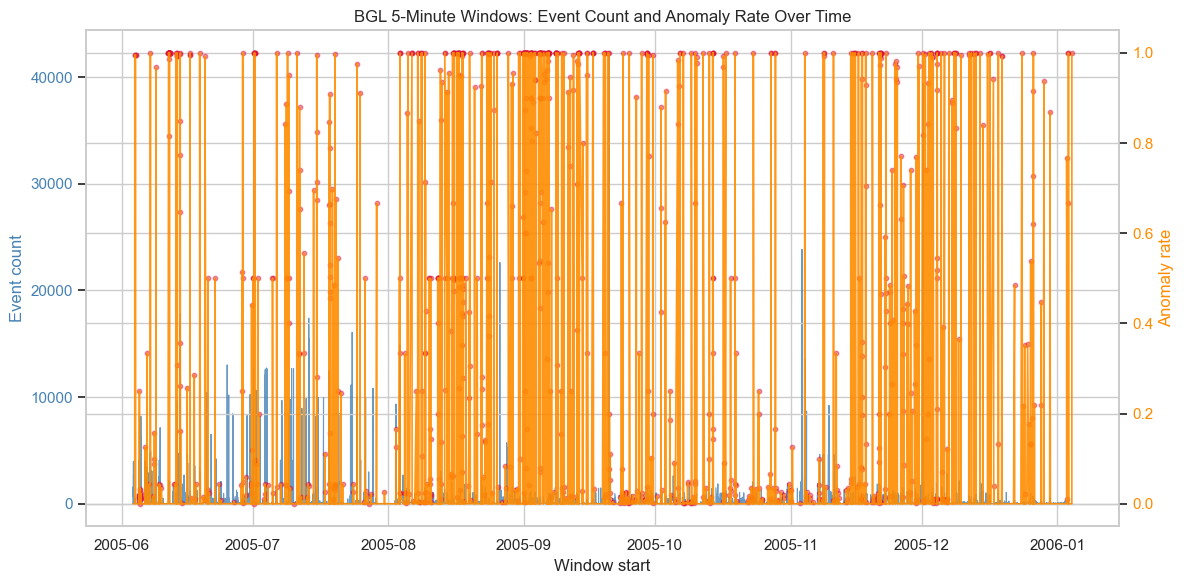

Saved manual-feature visualization to: /Users/yangjiening/Documents/CMU/Courses/18752 estimation detection and learning/log-ml/artifacts/bgl_log_feature_extraction/bgl_manual_window_features_over_time.png


In [17]:
# Visualization requirement using 5-minute window features
viz_df = window_df[['window_start', 'event_count', 'anomaly_rate', 'is_anomaly']].copy()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(viz_df['window_start'], viz_df['event_count'], color='steelblue', linewidth=0.8, alpha=0.8, label='Event count')
ax1.set_title('BGL 5-Minute Windows: Event Count and Anomaly Rate Over Time')
ax1.set_xlabel('Window start')
ax1.set_ylabel('Event count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(viz_df['window_start'], viz_df['anomaly_rate'], color='darkorange', linewidth=1.2, alpha=0.9, label='Anomaly rate')
ax2.scatter(
    viz_df.loc[viz_df['is_anomaly'] == 1, 'window_start'],
    viz_df.loc[viz_df['is_anomaly'] == 1, 'anomaly_rate'],
    color='crimson',
    s=10,
    alpha=0.45,
    label='Anomalous windows',
)
ax2.set_ylabel('Anomaly rate', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

fig.tight_layout()
manual_viz_path = artifacts_dir / 'bgl_manual_window_features_over_time.png'
plt.savefig(manual_viz_path, dpi=180, bbox_inches='tight')
plt.show()

print('Saved manual-feature visualization to:', manual_viz_path)

## Method 2: LDA Topic Feature Extraction
Each 5-minute window is treated as a document and transformed into topic-distribution features using Latent Dirichlet Allocation (LDA).

In [17]:
lda_docs = window_df['window_text'].fillna('')
count_vectorizer = CountVectorizer(max_features=2500, min_df=3, ngram_range=(1, 2), stop_words='english')
X_counts = count_vectorizer.fit_transform(lda_docs)

n_topics = 8
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42, learning_method='batch')
X_topics = lda_model.fit_transform(X_counts)

topic_cols = [f'lda_topic_{i}' for i in range(n_topics)]
topic_df = pd.DataFrame(X_topics, columns=topic_cols, index=window_df.index)
window_df = pd.concat([window_df, topic_df], axis=1)
window_df['dominant_topic'] = topic_df.to_numpy().argmax(axis=1)

vocab = np.array(count_vectorizer.get_feature_names_out())
top_k = 10
topic_keywords = {}
for i, topic_weights in enumerate(lda_model.components_):
    top_idx = np.argsort(topic_weights)[-top_k:][::-1]
    topic_keywords[f'topic_{i}'] = ', '.join(vocab[top_idx])

topic_keywords_df = pd.DataFrame(
    [{'topic': key, 'top_terms': value} for key, value in topic_keywords.items()]
)

lda_feature_cols = ['window_start', 'window_end', 'is_anomaly', 'dominant_topic'] + topic_cols
lda_window_features = window_df[lda_feature_cols].copy()

display(topic_keywords_df)
display(lda_window_features.head(10))
print('LDA feature columns:', len(topic_cols))

,topic,top_terms
0,topic_0,"interrupt, address, data, instruction, program..."
1,topic_1,"core, generating, generating core, auselton bg..."
2,topic_2,"microseconds, dear, iar, input, critical input..."
3,topic_3,"ciod, program, error, ciod error, invalid, mis..."
4,topic_4,"error, cache, parity, parity error, corrected,..."
5,topic_5,"ce, ce sym, sym, mask, detected, detected corr..."
6,topic_6,"alignment, exceptions, alignment exceptions, h..."
7,topic_7,"source, assert, idotransportmgr, node, card, f..."


,window_start,window_end,is_anomaly,dominant_topic,lda_topic_0,lda_topic_1,lda_topic_2,lda_topic_3,lda_topic_4,lda_topic_5,lda_topic_6,lda_topic_7
0,2005-06-03 15:40:00,2005-06-03 15:45:00,0,4,0.000019,0.000019,0.000019,0.000019,0.999864,0.000019,0.000019,0.000019
1,2005-06-03 15:45:00,2005-06-03 15:50:00,0,4,0.000008,0.000008,0.000008,0.000008,0.999945,0.000008,0.000008,0.000008
2,2005-06-03 15:50:00,2005-06-03 15:55:00,0,4,0.000010,0.003795,0.000010,0.000010,0.996147,0.000010,0.000010,0.000010
3,2005-06-03 15:55:00,2005-06-03 16:00:00,0,4,0.000014,0.000014,0.000014,0.000014,0.999904,0.000014,0.000014,0.000014
4,2005-06-03 16:00:00,2005-06-03 16:05:00,0,4,0.000027,0.005458,0.000027,0.000027,0.983298,0.011109,0.000027,0.000027
5,2005-06-03 16:05:00,2005-06-03 16:10:00,0,4,0.003125,0.385478,0.003125,0.003127,0.444277,0.154617,0.003125,0.003126
6,2005-06-03 16:10:00,2005-06-03 16:15:00,0,5,0.000206,0.000206,0.000206,0.000206,0.000206,0.996949,0.000206,0.001814
7,2005-06-03 16:15:00,2005-06-03 16:20:00,0,3,0.000106,0.010275,0.000106,0.814081,0.000106,0.175113,0.000106,0.000106
8,2005-06-03 16:25:00,2005-06-03 16:30:00,0,5,0.000862,0.000862,0.000862,0.000862,0.000862,0.993965,0.000862,0.000862
9,2005-06-03 16:30:00,2005-06-03 16:35:00,0,4,0.009615,0.009616,0.009615,0.009622,0.699185,0.243113,0.009615,0.009618


LDA feature columns: 8


## Method 3: TF-IDF Text Features
Each 5-minute window is treated as one document by concatenating the messages inside that window, then TF-IDF and SVD are applied for visualization and downstream classification.

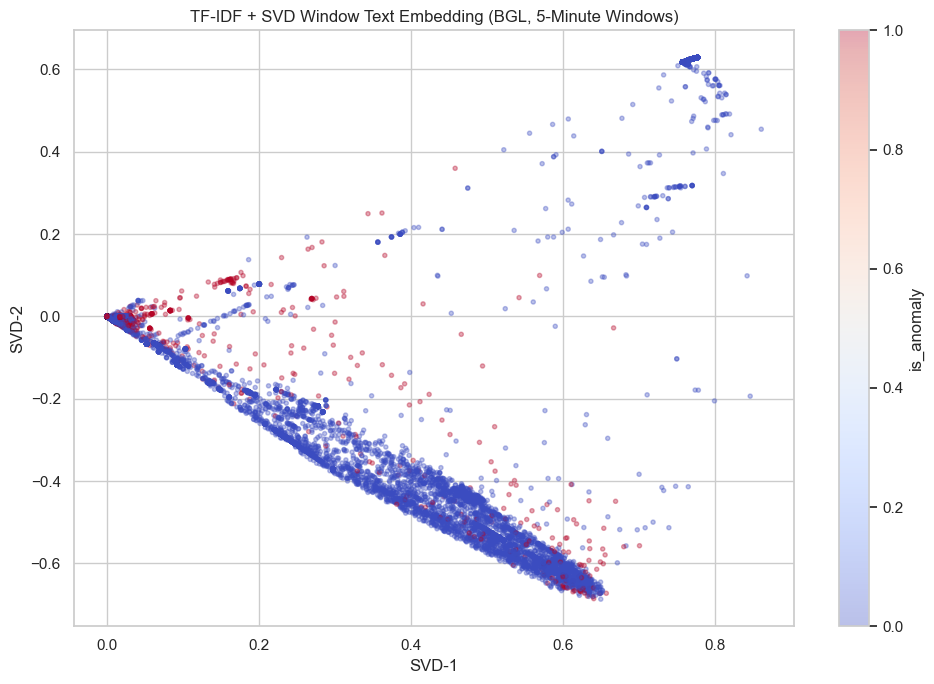

SVD explained variance ratio: [0.09328994 0.17944784]
Saved text-feature visualization to: /Users/yangjiening/Documents/CMU/Courses/18752 estimation detection and learning/log-ml/artifacts/bgl_log_feature_extraction/bgl_window_tfidf_svd_density.png


In [12]:
text_for_viz = window_df['window_text'].fillna('')
tfidf_viz = TfidfVectorizer(max_features=1500, min_df=3, ngram_range=(1, 2), stop_words='english')
X_viz = tfidf_viz.fit_transform(text_for_viz)

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_viz)

plot2_df = pd.DataFrame({
    'x': X_2d[:, 0],
    'y': X_2d[:, 1],
    'is_anomaly': window_df['is_anomaly'].to_numpy(),
    'window_start': window_df['window_start'].to_numpy(),
})
step = max(1, len(plot2_df) // 50000)
plot2_df = plot2_df.iloc[::step].copy()

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    plot2_df['x'],
    plot2_df['y'],
    c=plot2_df['is_anomaly'],
    cmap='coolwarm',
    s=9,
    alpha=0.35,
)
plt.colorbar(scatter, label='is_anomaly')
plt.title('TF-IDF + SVD Window Text Embedding (BGL, 5-Minute Windows)')
plt.xlabel('SVD-1')
plt.ylabel('SVD-2')
plt.tight_layout()

tfidf_viz_path = artifacts_dir / 'bgl_window_tfidf_svd_density.png'
plt.savefig(tfidf_viz_path, dpi=180, bbox_inches='tight')
plt.show()

print('SVD explained variance ratio:', svd.explained_variance_ratio_)
print('Saved text-feature visualization to:', tfidf_viz_path)

In [13]:
# Classification requirement using TF-IDF features on 5-minute windows
clf_df = window_df[['window_start', 'window_text', 'is_anomaly']].dropna().sort_values('window_start').reset_index(drop=True)
if len(clf_df) < 10:
    raise ValueError('Not enough 5-minute windows for classification.')

split_idx = int(len(clf_df) * 0.8)
split_idx = min(max(split_idx, 1), len(clf_df) - 1)
train_df = clf_df.iloc[:split_idx].copy()
test_df = clf_df.iloc[split_idx:].copy()

clf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=3, ngram_range=(1, 2), stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
])

clf_pipeline.fit(train_df['window_text'], train_df['is_anomaly'])
pred = clf_pipeline.predict(test_df['window_text'])
proba = clf_pipeline.predict_proba(test_df['window_text'])[:, 1]

print('Train windows:', len(train_df))
print('Test windows:', len(test_df))
print('F1 score:', f1_score(test_df['is_anomaly'], pred))
if test_df['is_anomaly'].nunique() > 1:
    print('ROC-AUC:', roc_auc_score(test_df['is_anomaly'], proba))
else:
    print('ROC-AUC: skipped because the test split contains one class only')
print('Confusion matrix:\n', confusion_matrix(test_df['is_anomaly'], pred))
print('Classification report:\n', classification_report(test_df['is_anomaly'], pred, digits=4))

Train windows: 11595
Test windows: 2899
F1 score: 0.7596330275229358
ROC-AUC: 0.978196625945317
Confusion matrix:
 [[2561  113]
 [  18  207]]
Classification report:
               precision    recall  f1-score   support

           0     0.9930    0.9577    0.9751      2674
           1     0.6469    0.9200    0.7596       225

    accuracy                         0.9548      2899
   macro avg     0.8199    0.9389    0.8673      2899
weighted avg     0.9662    0.9548    0.9583      2899



## Manual-features-only classifier

**Logistic regression** on **scaled numeric window aggregates** only—the same windows and **chronological 80/20 split** as the TF-IDF baseline (`clf_df` merged on `window_start`). **`anomaly_count`** and **`anomaly_rate`** are excluded because they are derived from the same BGL line labels as **`is_anomaly`** (label leakage).

In [19]:
# Manual-only classification (numeric window features, same split as TF-IDF baseline)
manual_only_cols = [c for c in manual_feature_cols if c not in ('anomaly_count', 'anomaly_rate')]

manual_clf_df = clf_df[['window_start', 'is_anomaly']].merge(
    window_df[['window_start'] + manual_only_cols],
    on='window_start',
    how='left',
)
if manual_clf_df[manual_only_cols].isna().any().any():
    manual_clf_df = manual_clf_df.dropna(subset=manual_only_cols)

manual_clf_df = manual_clf_df.sort_values('window_start').reset_index(drop=True)
split_idx_m = int(len(manual_clf_df) * 0.8)
split_idx_m = min(max(split_idx_m, 1), len(manual_clf_df) - 1)
train_m = manual_clf_df.iloc[:split_idx_m].copy()
test_m = manual_clf_df.iloc[split_idx_m:].copy()

manual_pipeline = Pipeline(
    [
        ('scale', StandardScaler()),
        (
            'clf',
            LogisticRegression(max_iter=2500, class_weight='balanced', random_state=42),
        ),
    ]
)

x_train_m = train_m[manual_only_cols]
x_test_m = test_m[manual_only_cols]
manual_pipeline.fit(x_train_m, train_m['is_anomaly'])
pred_m = manual_pipeline.predict(x_test_m)
proba_m = manual_pipeline.predict_proba(x_test_m)[:, 1]

print('Manual-features-only (scaled logistic regression)')
print('Train windows:', len(train_m), '| Test windows:', len(test_m))
print('Numeric columns:', len(manual_only_cols))
print('F1 score:', f1_score(test_m['is_anomaly'], pred_m))
if test_m['is_anomaly'].nunique() > 1:
    print('ROC-AUC:', roc_auc_score(test_m['is_anomaly'], proba_m))
else:
    print('ROC-AUC: skipped (test split is single-class)')
print('Confusion matrix:\n', confusion_matrix(test_m['is_anomaly'], pred_m))
print('Classification report:\n', classification_report(test_m['is_anomaly'], pred_m, digits=4))

Manual-features-only (scaled logistic regression)
Train windows: 11595 | Test windows: 2899
Numeric columns: 24
F1 score: 0.456441717791411
ROC-AUC: 0.9348042882074296
Confusion matrix:
 [[2270  404]
 [  39  186]]
Classification report:
               precision    recall  f1-score   support

           0     0.9831    0.8489    0.9111      2674
           1     0.3153    0.8267    0.4564       225

    accuracy                         0.8472      2899
   macro avg     0.6492    0.8378    0.6838      2899
weighted avg     0.9313    0.8472    0.8758      2899



## Joint model: numeric window features + TF-IDF → SVD

Uses the **same chronological 80/20 time split** as the TF-IDF-only baseline.

- **Text branch:** `TfidfVectorizer` → `TruncatedSVD` to a fixed number of dense components (sparse TF-IDF is not fed directly into logistic regression together with scaled numerics).
- **Numeric branch:** `StandardScaler` on Method 1 per-window aggregates, **excluding** `anomaly_count` and `anomaly_rate` (same information as `is_anomaly`, would leak labels).
- **Classifier:** one `LogisticRegression` on the **horizontally stacked** outputs of both branches (`ColumnTransformer`).

This lets the model use both lexical patterns (via SVD of TF-IDF) and volume / rate / inter-arrival statistics from the same window.

In [14]:
# Joint classification: numeric window features + TF-IDF -> TruncatedSVD
# Exclude anomaly_count / anomaly_rate: they are derived from the same BGL line labels as is_anomaly (label leakage).
numeric_cols = [c for c in manual_feature_cols if c not in ('anomaly_count', 'anomaly_rate')]

joint_df = window_df[['window_start', 'window_text', 'is_anomaly'] + numeric_cols].dropna()
joint_df = joint_df.sort_values('window_start').reset_index(drop=True)
if len(joint_df) < 10:
    raise ValueError('Not enough windows for joint classification.')

split_idx_joint = int(len(joint_df) * 0.8)
split_idx_joint = min(max(split_idx_joint, 1), len(joint_df) - 1)
train_joint = joint_df.iloc[:split_idx_joint].copy()
test_joint = joint_df.iloc[split_idx_joint:].copy()

svd_components = 128
preprocess_joint = ColumnTransformer(
    transformers=[
        (
            'text_svd',
            Pipeline(
                [
                    (
                        'tfidf',
                        TfidfVectorizer(
                            max_features=5000,
                            min_df=3,
                            ngram_range=(1, 2),
                            stop_words='english',
                        ),
                    ),
                    (
                        'svd',
                        TruncatedSVD(n_components=svd_components, random_state=42),
                    ),
                ]
            ),
            'window_text',
        ),
        ('numeric_scaled', StandardScaler(), numeric_cols),
    ]
)

joint_pipeline = Pipeline(
    [
        ('prep', preprocess_joint),
        (
            'clf',
            LogisticRegression(max_iter=2500, class_weight='balanced', random_state=42),
        ),
    ]
)

x_train_joint = train_joint.drop(columns=['window_start', 'is_anomaly'])
x_test_joint = test_joint.drop(columns=['window_start', 'is_anomaly'])
joint_pipeline.fit(x_train_joint, train_joint['is_anomaly'])

pred_joint = joint_pipeline.predict(x_test_joint)
proba_joint = joint_pipeline.predict_proba(x_test_joint)[:, 1]

print('Joint model (numeric + TF-IDF SVD)')
print('Train windows:', len(train_joint), '| Test windows:', len(test_joint))
print('SVD components:', svd_components, '| Numeric features:', len(numeric_cols))
print('F1 score:', f1_score(test_joint['is_anomaly'], pred_joint))
if test_joint['is_anomaly'].nunique() > 1:
    print('ROC-AUC:', roc_auc_score(test_joint['is_anomaly'], proba_joint))
else:
    print('ROC-AUC: skipped (test split is single-class)')
print('Confusion matrix:\n', confusion_matrix(test_joint['is_anomaly'], pred_joint))
print('Classification report:\n', classification_report(test_joint['is_anomaly'], pred_joint, digits=4))

Joint model (numeric + TF-IDF SVD)
Train windows: 11595 | Test windows: 2899
SVD components: 128 | Numeric features: 24
F1 score: 0.8713692946058091
ROC-AUC: 0.9849530457907422
Confusion matrix:
 [[2627   47]
 [  15  210]]
Classification report:
               precision    recall  f1-score   support

           0     0.9943    0.9824    0.9883      2674
           1     0.8171    0.9333    0.8714       225

    accuracy                         0.9786      2899
   macro avg     0.9057    0.9579    0.9299      2899
weighted avg     0.9806    0.9786    0.9793      2899



In [15]:
# Export 5-minute window feature tables
window_features = window_df.drop(columns=['window_text']).copy()
window_text_docs = window_df[['window_start', 'window_end', 'is_anomaly', 'window_text']].copy()

features_path = artifacts_dir / 'bgl_window_features_5min.csv'
text_docs_path = artifacts_dir / 'bgl_window_text_5min.csv'
lda_topics_path = artifacts_dir / 'bgl_lda_topics.csv'
sample_path = artifacts_dir / 'bgl_window_sample.csv'

window_features.to_csv(features_path, index=False)
window_text_docs.to_csv(text_docs_path, index=False)
if 'topic_keywords_df' in globals():
    topic_keywords_df.to_csv(lda_topics_path, index=False)
window_df.head(1000).to_csv(sample_path, index=False)

print('Saved window feature table to:', features_path)
print('Saved window text documents to:', text_docs_path)
if 'topic_keywords_df' in globals():
    print('Saved LDA topic summary to:', lda_topics_path)
print('Saved sample window table to:', sample_path)
print('Final windows:', len(window_features))
print('Anomalous windows:', int(window_features['is_anomaly'].sum()))

Saved window feature table to: /Users/yangjiening/Documents/CMU/Courses/18752 estimation detection and learning/log-ml/artifacts/bgl_log_feature_extraction/bgl_window_features_5min.csv
Saved window text documents to: /Users/yangjiening/Documents/CMU/Courses/18752 estimation detection and learning/log-ml/artifacts/bgl_log_feature_extraction/bgl_window_text_5min.csv
Saved sample window table to: /Users/yangjiening/Documents/CMU/Courses/18752 estimation detection and learning/log-ml/artifacts/bgl_log_feature_extraction/bgl_window_sample.csv
Final windows: 14494
Anomalous windows: 1054
